In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [2]:
custdf = pd.read_csv("custdata.tsv", sep="\t")

In [3]:
custdf.shape

(1000, 11)

In [4]:
custdf.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [5]:
custdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 115.8+ KB


In [6]:
custdf.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


In [7]:
custdf.isna().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

In [8]:
custdf["housing.type"].isna().sum()

np.int64(56)

<Axes: >

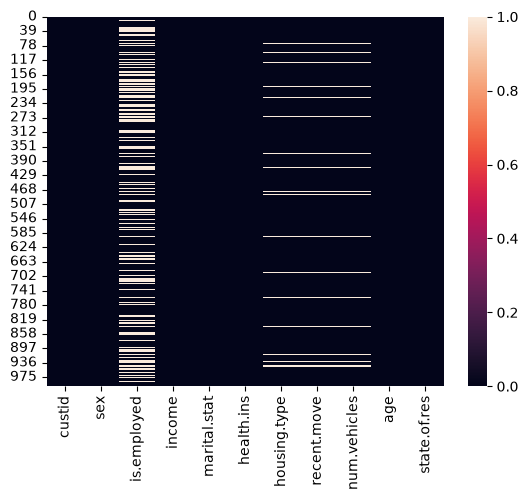

In [9]:
sns.heatmap(custdf.isna())

In [10]:
custdf[ custdf["housing.type"].isna() ]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
17,26057,M,True,30000,Married,True,NaN,NaN,NaN,28.0,Florida
55,68013,M,NaN,100,Divorced/Separated,False,NaN,NaN,NaN,28.0,California
72,90303,M,NaN,0,Never Married,False,NaN,NaN,NaN,45.0,Kentucky
96,115100,M,NaN,0,Never Married,False,NaN,NaN,NaN,29.0,California
123,151678,M,NaN,0,Never Married,False,NaN,NaN,NaN,34.0,Georgia
133,167154,M,NaN,0,Never Married,False,NaN,NaN,NaN,31.0,New Jersey
177,220142,F,NaN,0,Never Married,True,NaN,NaN,NaN,18.0,Arkansas
188,249492,F,NaN,10100,Widowed,True,NaN,NaN,NaN,93.0,Georgia
196,259807,M,NaN,440,Married,True,NaN,NaN,NaN,49.0,West Virginia
200,268667,M,NaN,200,Never Married,True,NaN,NaN,NaN,31.0,Pennsylvania


In [11]:
custdf["housing.type"] = pd.Categorical(custdf["housing.type"])

In [12]:
custdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   custid        1000 non-null   int64   
 1   sex           1000 non-null   str     
 2   is.employed   672 non-null    object  
 3   income        1000 non-null   int64   
 4   marital.stat  1000 non-null   str     
 5   health.ins    1000 non-null   bool    
 6   housing.type  944 non-null    category
 7   recent.move   944 non-null    object  
 8   num.vehicles  944 non-null    float64 
 9   age           1000 non-null   float64 
 10  state.of.res  1000 non-null   str     
dtypes: bool(1), category(1), float64(2), int64(2), object(2), str(3)
memory usage: 91.7+ KB


In [13]:
print(custdf["housing.type"].unique())

['Homeowner free and clear', 'Rented', 'Occupied with no rent', 'Homeowner with mortgage/loan', NaN]
Categories (4, str): ['Homeowner free and clear', 'Homeowner with mortgage/loan', 'Occupied with no rent', 'Rented']


In [14]:
custdf.groupby("housing.type").count()

,custid,sex,is.employed,income,marital.stat,health.ins,recent.move,num.vehicles,age,state.of.res
housing.type,,,,,,,,,,
Homeowner free and clear,157,157,61,157,157,157,157,157,157,157
Homeowner with mortgage/loan,412,412,323,412,412,412,412,412,412,412
Occupied with no rent,11,11,8,11,11,11,11,11,11,11
Rented,364,364,272,364,364,364,364,364,364,364


In [15]:
custdf["housing.type"].dropna()

0      Homeowner free and clear
1                        Rented
2                        Rented
3         Occupied with no rent
4                        Rented
                 ...           
994    Homeowner free and clear
995                      Rented
997                      Rented
998    Homeowner free and clear
999                      Rented
Name: housing.type, Length: 944, dtype: category
Categories (4, str): ['Homeowner free and clear', 'Homeowner with mortgage/loan', 'Occupied with no rent', 'Rented']

In [16]:
custdf.shape

(1000, 11)

In [17]:
custdf.dropna(subset=["housing.type"])

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
994,1409249,M,NaN,36200,Married,True,Homeowner free and clear,False,5.0,73.0,New York
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


In [18]:
custdf = custdf.dropna(subset=["housing.type"])

In [19]:
custdf.shape

(944, 11)

<function matplotlib.pyplot.show(close=None, block=None)>

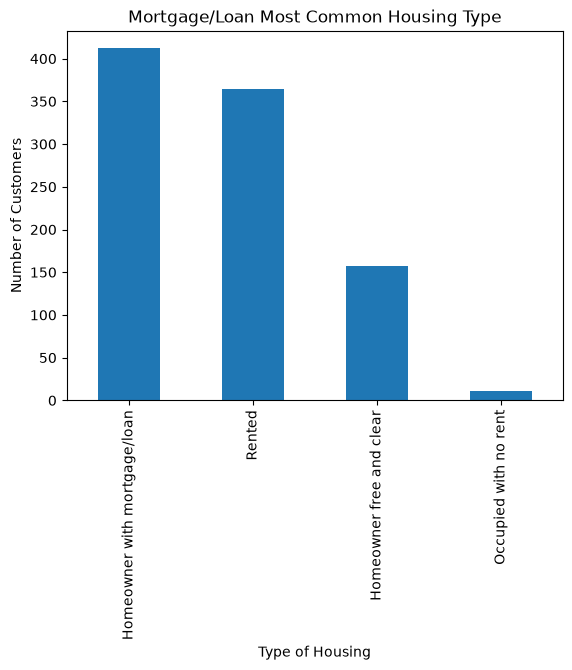

In [20]:
custdf["housing.type"].value_counts().plot(kind="bar")
plt.title("Mortgage/Loan Most Common Housing Type")
plt.xlabel("Type of Housing")
plt.ylabel("Number of Customers")
plt.show

Out of the 1000-row total of this dataset, 56 rows were missing a value for the "housing.type" column and were therefore excluded. The distribution of "housing.type" categories was then visualized using a sorted bar chart.

<p>I consulted the pandas User Guide, the seaborn User Guide, the website Geeks for Geeks, and various Stack Overflow threads:</p>

<p>https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html<br/>
https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html#categorical-sort<br/>
https://seaborn.pydata.org/generated/seaborn.barplot.html<br/>
https://www.geeksforgeeks.org/machine-learning/seaborn-categorical-plots/<br/>
https://www.geeksforgeeks.org/python/how-to-count-observations-by-group-in-pandas/<br/>
https://stackoverflow.com/questions/52404971/get-a-list-of-categories-of-categorical-variable<br/>
https://stackoverflow.com/questions/74764275/convert-string-object-datatype-to-categorical-data</p>

Github Repo Url: https://github.com/journeyrahman/cs82a-portfolio